In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [20]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [21]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [22]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [23]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [24]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [25]:
dados.columns = dados.columns.str.strip()

In [26]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [27]:
# Organização dos dados (médias mensais) — conforme roteiro da professora
# Obs.: PV não está disponível no banco; usamos Radiação como proxy do potencial fotovoltaico.
dados["Data"] = pd.to_datetime(dados["Data"])
dados["Ano"] = dados["Data"].dt.year
dados["Mes"] = dados["Data"].dt.month

colunas_modelo = [
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração",
]

dados_mensal = (
    dados.groupby(["Ano", "Mes"], as_index=False)[colunas_modelo]
    .mean()
 )

dados_modelo = dados_mensal[colunas_modelo]

In [28]:
dados_modelo.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,212.873711,26.215695,1.568404,1.337431
1,212.720812,26.794226,0.693598,1.201496
2,184.303724,26.258626,5.963765,2.701673
3,167.516251,25.147269,8.661961,3.607780
4,152.255352,24.569632,9.284964,3.258404


In [29]:
dados_modelo.isna().sum()

W/m² - Radiação               0
C° - Temperatura Média        0
mm/dia - Precipitação         0
mm/dia - Evapotranspiração    0
dtype: int64

In [30]:
X = dados_modelo[[
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração"
]]

y = dados_modelo["W/m² - Radiação"]

In [31]:
X.head()

,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,26.215695,1.568404,1.337431
1,26.794226,0.693598,1.201496
2,26.258626,5.963765,2.701673
3,25.147269,8.661961,3.607780
4,24.569632,9.284964,3.258404


In [32]:
y.head()

0    212.873711
1    212.720812
2    184.303724
3    167.516251
4    152.255352
Name: W/m² - Radiação, dtype: float64

In [33]:
modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo_multiplo.coef_
})

coeficientes

,Variavel,Coeficiente
0,C° - Temperatura Média,10.259646
1,mm/dia - Precipitação,-5.443839
2,mm/dia - Evapotranspiração,3.165629


In [35]:
intercepto = modelo_multiplo.intercept_

print("Intercepto:", intercepto)

Intercepto: -65.62542250284804


In [36]:
r2 = modelo_multiplo.score(X, y)

print("R²:", r2)

R²: 0.6989465657553595


In [37]:
print("Modelo estimado:")

coef_T, coef_P, coef_ET = modelo_multiplo.coef_

def fmt_signed(valor: float) -> str:
    return f"+ {abs(valor):.3f}" if valor >= 0 else f"- {abs(valor):.3f}"

print(
    f"PV = {intercepto:.3f} {fmt_signed(coef_T)} * T {fmt_signed(coef_P)} * P {fmt_signed(coef_ET)} * ET"
 )

Modelo estimado:
PV = -65.625 + 10.260 * T - 5.444 * P + 3.166 * ET


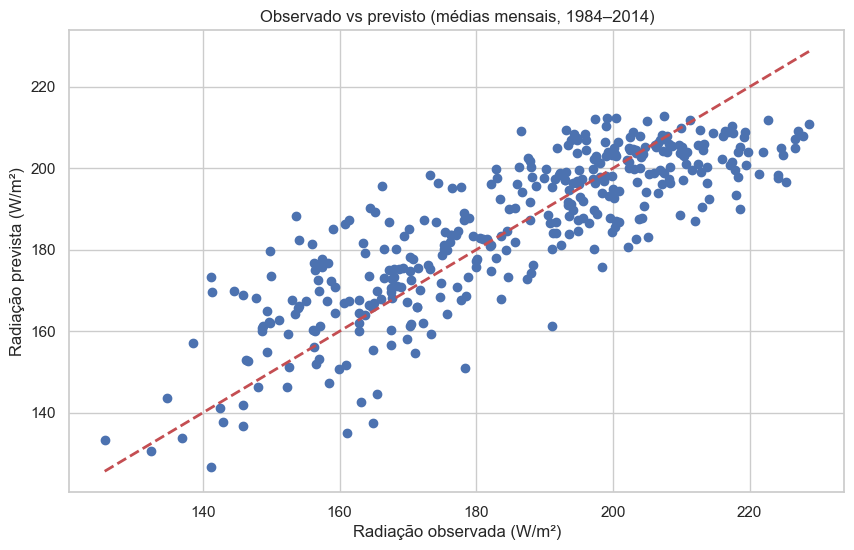

In [38]:
y_pred = modelo_multiplo.predict(X)

plt.scatter(y, y_pred)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.xlabel("Radiação observada (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.title("Observado vs previsto (médias mensais, 1984–2014)")

plt.show()

**Interpretação (Observado vs previsto).** Neste gráfico, cada ponto representa uma **média mensal** (1984–2014), comparando a radiação **observada** (eixo x) com a radiação **prevista** pelo modelo (eixo y).

- Pontos próximos da linha tracejada (linha 1:1) indicam **boa capacidade de previsão** do modelo para aquele mês.
- Se muitos pontos ficarem sistematicamente **acima** da linha, o modelo tende a **superestimar**; se ficarem **abaixo**, tende a **subestimar**.
- A dispersão em torno da linha mostra a **magnitude do erro**: quanto mais espalhados os pontos, maior a incerteza das previsões.

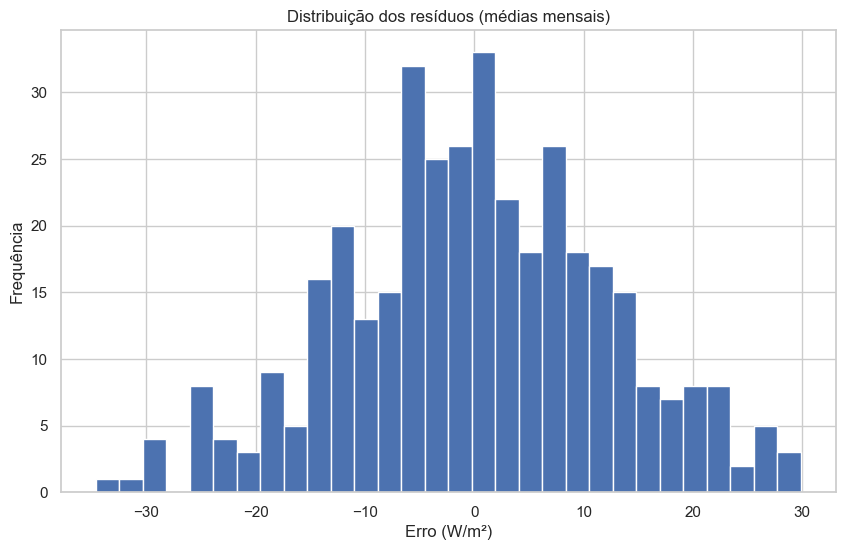

In [39]:
residuos = y - y_pred

plt.hist(residuos, bins=30)
plt.title("Distribuição dos resíduos (médias mensais)")
plt.xlabel("Erro (W/m²)")
plt.ylabel("Frequência")
plt.show()

**Interpretação (Resíduos).** O histograma mostra a distribuição dos **erros** (resíduo = observado − previsto) nas **médias mensais**.

- Resíduos concentrados em torno de **0** indicam que, em média, o modelo não apresenta viés forte (nem superestima nem subestima de forma sistemática).
- Uma distribuição aproximadamente **simétrica** sugere erros balanceados; assimetrias podem indicar tendência a errar mais para cima ou para baixo.
- Caudas longas (valores muito positivos/negativos) indicam meses com **erros maiores**, que podem estar associados a condições climáticas atípicas ou a limitações do modelo linear.

## 5. Modelagem do Potencial Fotovoltaico

Para esta etapa, foi utilizada a **regressão linear múltipla** com o objetivo de representar o **potencial fotovoltaico regional**. Como o conjunto de dados não contém a geração real de energia elétrica, adotou-se a **radiação solar** como **variável proxy** do potencial fotovoltaico, por ser o principal fator climático associado ao aproveitamento da energia solar.

Assim, o modelo ajustado considerou a **radiação** como variável resposta e a **temperatura média**, a **precipitação** e a **evapotranspiração** como variáveis explicativas. Para manter consistência com o roteiro da professora, o ajuste foi feito sobre **médias mensais** do período **1984–2014**.

---

## 5.1 Modelo teórico adotado

O modelo teórico pode ser representado por:

**PV = β₀ + β₁T + β₂P + β₃ET + ε**

onde:

- **PV** = potencial fotovoltaico regional representado pela radiação solar;
- **T** = temperatura média do ar;
- **P** = precipitação;
- **ET** = evapotranspiração;
- **β₀** = intercepto do modelo;
- **β₁, β₂, β₃** = coeficientes estimados;
- **ε** = erro aleatório.

---

## 5.2 Modelo estimado

A regressão linear múltipla ajustada às **médias mensais** resultou na seguinte equação:

**PV = -65,625 + 10,260T - 5,444P + 3,166ET**

com:

**R² = 0,699**

---

## 5.3 Interpretação dos coeficientes

A interpretação prática dos coeficientes mostra que:

- a **temperatura média** apresentou coeficiente positivo, indicando que o aumento da temperatura tende a elevar a radiação estimada e, consequentemente, o potencial fotovoltaico representado no modelo;
- a **precipitação** apresentou coeficiente negativo, indicando que o aumento das chuvas tende a reduzir a radiação disponível (por maior nebulosidade e menor incidência solar);
- a **evapotranspiração** apresentou coeficiente positivo, sugerindo associação com condições atmosféricas mais secas e maior disponibilidade de radiação no período mensal.

---

## 5.4 Interpretação do R²

O coeficiente de determinação encontrado foi **R² = 0,699**, o que indica que o modelo consegue explicar aproximadamente **69,9% da variabilidade da radiação solar** a partir das variáveis climáticas utilizadas.

Isso sugere um ajuste de capacidade explicativa **moderada a alta**, adequado para representar o potencial fotovoltaico de forma indireta no contexto do conjunto de dados disponível.

---

## 5.5 Interpretação geral

Os resultados mostram que o potencial fotovoltaico regional, representado pela radiação solar, tende a ser:

- **maior em condições de temperaturas mais elevadas**;
- **menor em períodos de maior precipitação**;
- **maior quando a evapotranspiração é mais elevada**, de forma consistente com condições de maior disponibilidade energética e menor umidade.

Dessa forma, o modelo confirma que a radiação solar pode ser utilizada como um indicador climático relevante para representar o potencial fotovoltaico da região.

---

## 5.6 Conclusão da etapa

A modelagem realizada está de acordo com a proposta da etapa, pois utilizou a **regressão múltipla** (com base em **médias mensais**) para representar o **potencial fotovoltaico regional** a partir de variáveis climáticas. Como não havia dados de geração elétrica real, a **radiação solar foi adotada como proxy do potencial fotovoltaico**, permitindo analisar de forma estatística como temperatura, precipitação e evapotranspiração influenciam esse potencial.

Portanto, a análise mostra que o procedimento adotado é metodologicamente coerente com o objetivo da atividade e adequado para representar o potencial fotovoltaico de forma indireta.